# Tutorial: Fuzzy Averaging + Mutual Information Scan

This notebook demonstrates how to use the functions in `colocalization/functions/tools.py` to:

1. Load or reuse an `AnnData` object
2. Build fuzzy (neighbor-averaged) expression
3. Compute gene-wise mutual information against a seed gene
4. Run attractor discovery from a seed gene
5. Export ranked results

In [9]:
from pathlib import Path
import os
import sys
import importlib

import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sc.set_figure_params(facecolor="white", figsize=(7, 6))
sc.settings.verbosity = 2

PROJECT_ROOT = Path("/Users/lingyi/Documents/spatial")
FUNCTIONS_DIR = PROJECT_ROOT / "colocalization" / "functions"
if str(FUNCTIONS_DIR) not in sys.path:
    sys.path.append(str(FUNCTIONS_DIR))

import tools
importlib.reload(tools)

print("Environment ready. Loaded tools from:")
print(FUNCTIONS_DIR)

Environment ready. Loaded tools from:
/Users/lingyi/Documents/spatial/colocalization/functions


## 1) Load data (runnable example)

- `dataset_name = "HTAN_WUSTL/scRNA_vali/raw_spatial"`
- `folder = "/Volumes/T7/datasets/" + dataset_name + "/"`
- `sampleID = "HT232P1H2A2"`
- load using `proc.dataprocess(pathfile, skip_qc=False)`

Selected sample: HT232P1H2A2
Loading from: /Volumes/T7/datasets/HTAN_WUSTL/scRNA_vali/raw_spatial/raw/HT232P1H2A2
reading /Volumes/T7/datasets/HTAN_WUSTL/scRNA_vali/raw_spatial/raw/HT232P1H2A2/filtered_feature_bc_matrix.h5


/Users/lingyi/Documents/spatial/colocalization/functions/tools.py:198: FutureWarning: Use `squidpy.read.visium` instead.
  adata = sc.read_visium(


 (0:00:00)
Loaded filtered_feature_bc_matrix.h5 from /Volumes/T7/datasets/HTAN_WUSTL/scRNA_vali/raw_spatial/raw/HT232P1H2A2 (no hires image)
→ Computed microns_per_pixel = 0.3030 µm/pixel
Added adata.obsm['spatial_um'] with coordinates in micrometers.
Filtered off-tissue spots: kept 4067 / 4992
Added lowres image, scalefactors, and spatial coords manually.
normalizing counts per cell
    finished (0:00:00)
computing PCA
    with n_comps=50
    finished (0:00:08)
computing neighbors
    using 'X_pca' with n_pcs = 50
    finished (0:00:00)
computing UMAP
    finished (0:00:03)
running Leiden clustering
    finished (0:00:00)


/Users/lingyi/Documents/spatial/colocalization/functions/tools.py:328: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata, img_key="lowres", color="clusters", size=1.5)


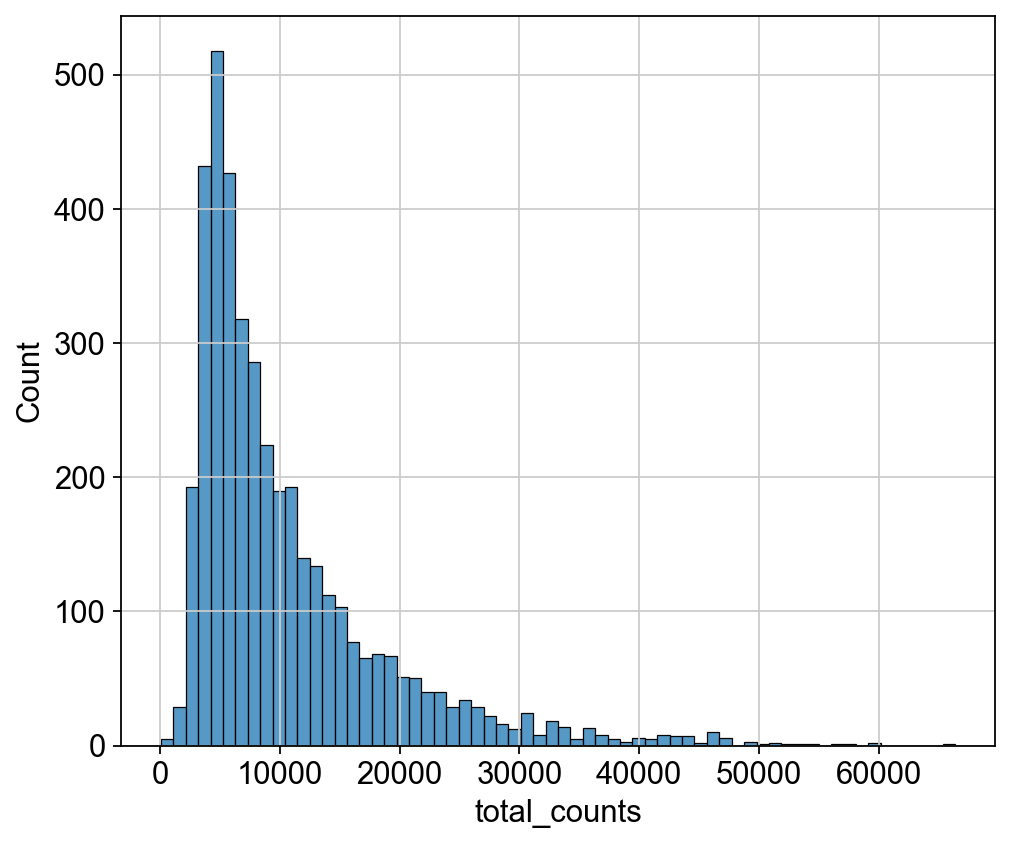

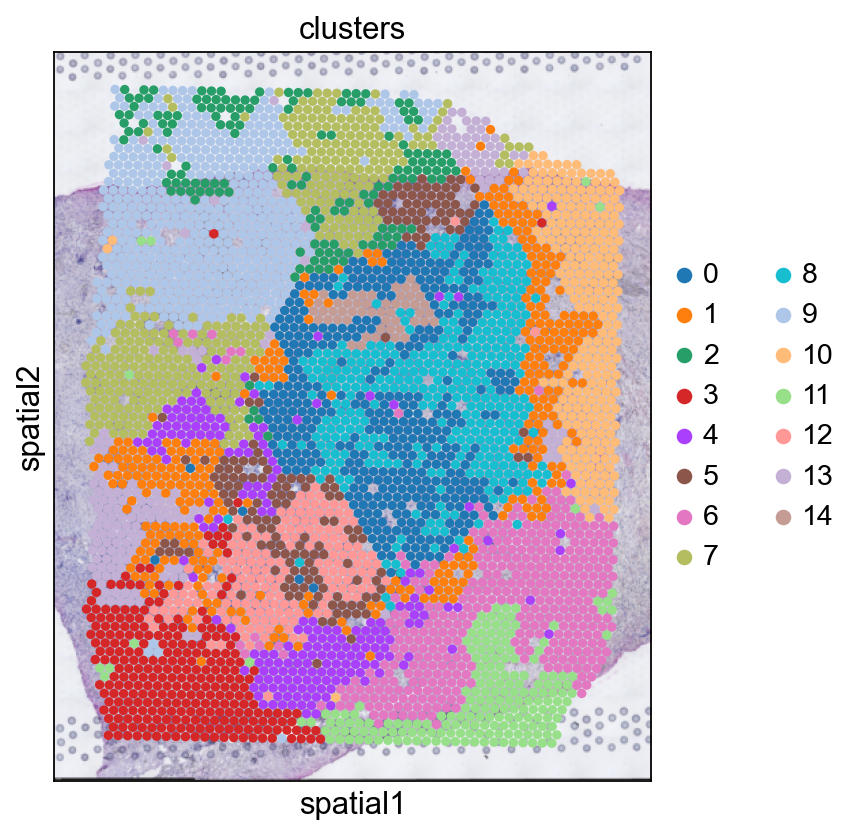

adata shape: (3985, 36601)


In [10]:
dataset_name = "HTAN_WUSTL/scRNA_vali/raw_spatial"
folder = "/Volumes/T7/datasets/" + dataset_name + "/"

sampleIDs = sorted(os.listdir(folder + "raw/"))
sampleID = "HT232P1H2A2"

if sampleID not in sampleIDs:
    raise ValueError(f"sampleID {sampleID} not found. Available examples: {sampleIDs[:10]}")

pathfile = folder + "raw/" + sampleID
if not os.path.exists(pathfile):
    raise FileNotFoundError(f"Sample path does not exist: {pathfile}")

print(f"Selected sample: {sampleID}")
print(f"Loading from: {pathfile}")

proc = tools.spatialTool()
adata = proc.dataprocess(pathfile, skip_qc=False)

adata.var_names_make_unique()
print(f"adata shape: {adata.shape}")

## 2) Build fuzzy expression

`FuzzyAverage.fuzzy_average` smooths each spot using neighboring spots.

Recommended starting parameters for Visium HD-like grid data:
- `coord_type="grid"`
- `n_neighs=6`
- `include_self=True`

In [11]:
fuzzyA = tools.FuzzyAverage()

X_fuzzy = fuzzyA.fuzzy_average(
    adata,
    layer_out="X_fuzzy",
    n_neighs=6,
    coord_type="grid",
    include_self=True,
    delaunay=False,
)

print("Created fuzzy expression matrix:", X_fuzzy.shape)
print("Stored in adata.layers['X_fuzzy']")

Creating graph using `grid` coordinates and `None` transform and `1` libraries.
Adding `adata.obsp['spatial_connectivities']`
       `adata.obsp['spatial_distances']`
       `adata.uns['spatial_neighbors']`
Finish (0:00:00)
Created fuzzy expression matrix: (3985, 36601)
Stored in adata.layers['X_fuzzy']


## 3) Mutual information scan

Compute MI between a seed gene and all genes in fuzzy expression.

- `normalize=True` gives normalized MI
- `negateMI=True` keeps sign based on product moment

In [12]:
SEED_GENE = "COL11A1"
TOP_N = 20

if SEED_GENE not in adata.var_names:
    raise ValueError(f"Seed gene '{SEED_GENE}' not found in adata.var_names.")

mi_calc = tools.FastMICalculateNumba()
seed_idx = adata.var_names.get_loc(SEED_GENE)
seed_vec = X_fuzzy[:, seed_idx]

mi_scores = mi_calc.mi_scan(
    seed_vec,
    X_fuzzy,
    num_bins=6,
    spline_order=3,
    normalize=True,
    negateMI=True,
)

results = pd.DataFrame({
    "gene": adata.var_names,
    "mi": mi_scores,
}).sort_values("mi", ascending=False).reset_index(drop=True)

print(f"Computed MI for {len(results)} genes against {SEED_GENE}.")
results.head(TOP_N)

Computed MI for 36601 genes against COL11A1.


,gene,mi
0,COL11A1,1.000000
1,TIMP3,0.486201
2,MFAP5,0.474767
3,LRRC15,0.449126
4,COL12A1,0.439128
5,FNDC1,0.388044
6,FN1,0.387826
7,COL8A1,0.353109
8,MXRA5,0.348453
9,NR4A1,0.346329


,gene,mi
0,COL11A1,1.000000
1,TIMP3,0.486201
2,MFAP5,0.474767
3,LRRC15,0.449126
4,COL12A1,0.439128
5,FNDC1,0.388044
6,FN1,0.387826
7,COL8A1,0.353109
8,MXRA5,0.348453
9,NR4A1,0.346329


,gene,mi
36600,APOD,-0.205374
36599,SFRP4,-0.183663
36598,COLEC11,-0.176198
36597,MGP,-0.166593
36596,CEACAM5,-0.165363
36595,ENG,-0.164297
36594,CEACAM6,-0.159482
36593,C7,-0.158255
36592,SOD3,-0.150538
36591,TM4SF1,-0.144963


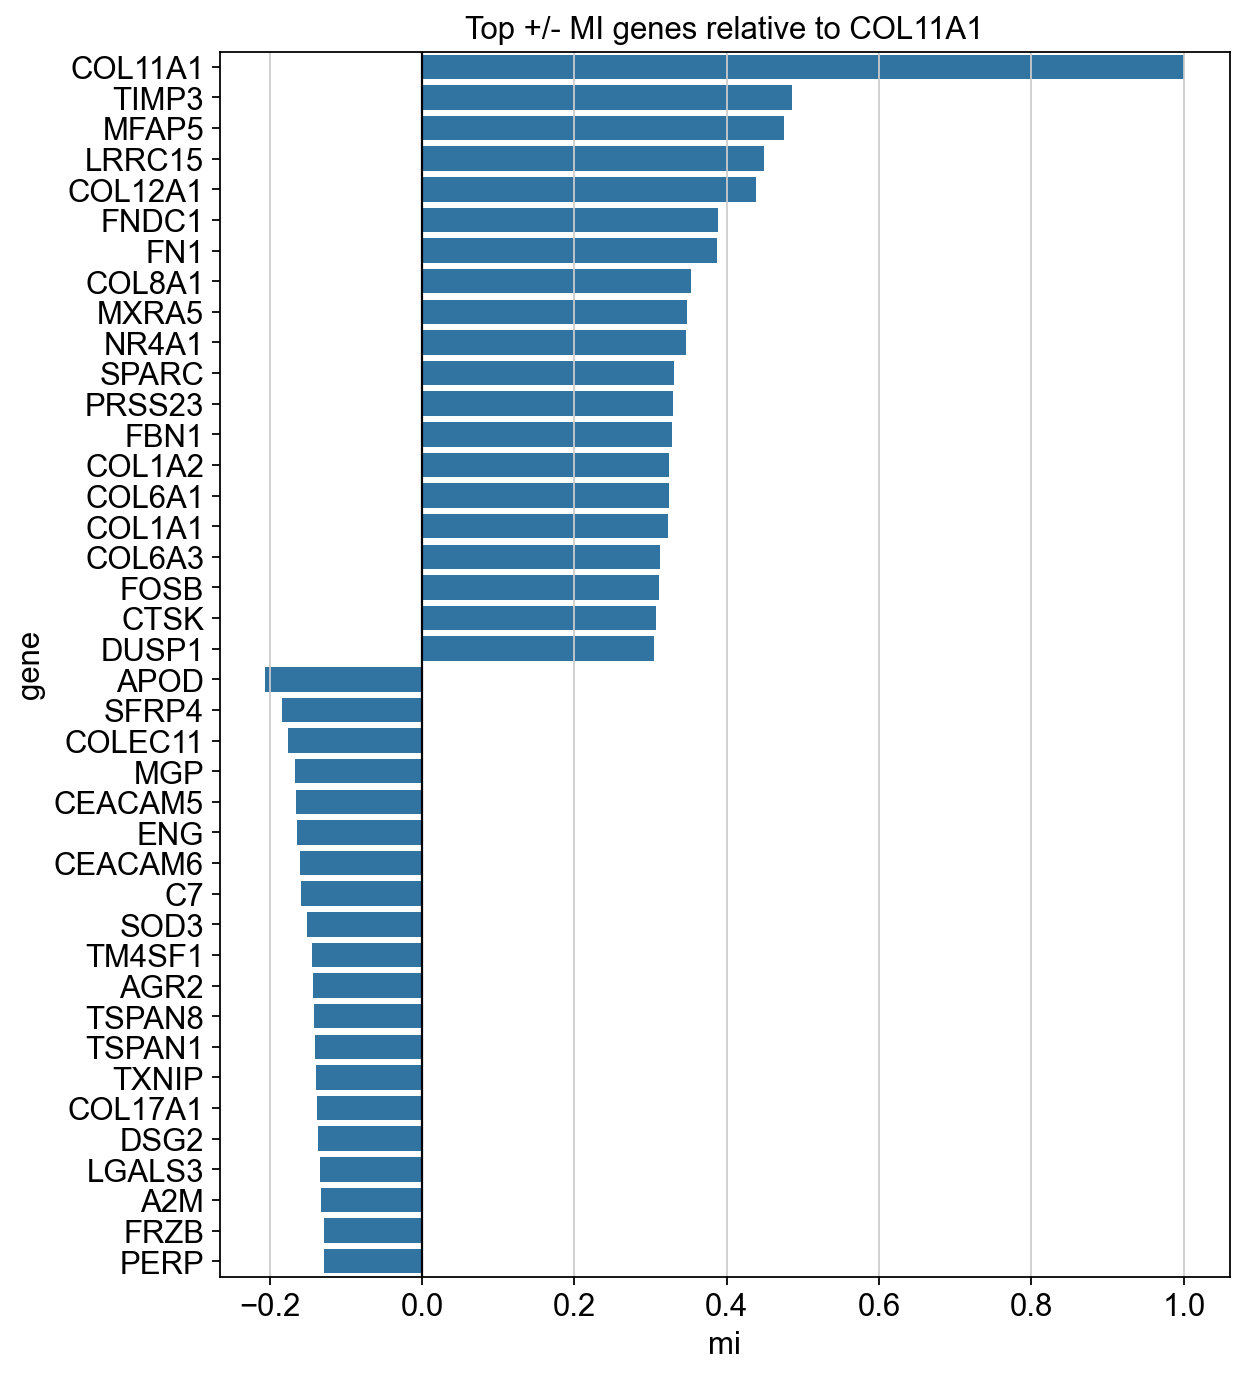

In [13]:
top_pos = results.head(TOP_N).copy()
top_neg = results.tail(TOP_N).sort_values("mi", ascending=True).copy()

display(top_pos)
display(top_neg)

plot_df = pd.concat([top_pos, top_neg], axis=0)
plt.figure(figsize=(8, max(5, 0.22 * len(plot_df))))
sns.barplot(data=plot_df, y="gene", x="mi", orient="h")
plt.axvline(0, color="black", linewidth=1)
plt.title(f"Top +/- MI genes relative to {SEED_GENE}")
plt.tight_layout()
plt.show()

## 4) Attractor example

Run attractor search aligned to the reference notebook style (TREM2, `a=3` and `a=5`).

Notes:
- `find_attractor` expects `data` as **genes × spots**
- here we pass `X_fuzzy.T`
- `epsilon=1e-7`, `num_bins=6`, `spline_order=3`

In [14]:
ATTRACTOR_GENE = "TREM2"
if ATTRACTOR_GENE not in adata.var_names:
    raise ValueError(f"Gene {ATTRACTOR_GENE} not found in adata.var_names")

gene_idx = adata.var_names.get_loc(ATTRACTOR_GENE)
gene_vals = X_fuzzy[:, gene_idx]

attr_a3 = mi_calc.find_attractor(
    data=X_fuzzy.T,
    vec=gene_vals,
    gene_names=np.asarray(adata.var_names),
    a=3,
    max_iter=100,
    epsilon=1e-7,
    num_bins=6,
    spline_order=3,
    rank_based=False,
    negate_mi=True,
    verbose=False,
)

attr_a5 = mi_calc.find_attractor(
    data=X_fuzzy.T,
    vec=gene_vals,
    gene_names=np.asarray(adata.var_names),
    a=5,
    max_iter=100,
    epsilon=1e-7,
    num_bins=6,
    spline_order=3,
    rank_based=False,
    negate_mi=True,
    verbose=False,
)

def _to_df(attractor_out):
    if isinstance(attractor_out, list):
        return pd.DataFrame(attractor_out, columns=["gene", "weight"])
    if isinstance(attractor_out, tuple) and len(attractor_out) == 2:
        if attractor_out[0] is None:
            return None
        weights, indices = attractor_out
        return pd.DataFrame({
            "gene": np.asarray(adata.var_names)[indices],
            "weight": weights,
        }).sort_values("weight", ascending=False).reset_index(drop=True)
    return None

attractor_a3_results = _to_df(attr_a3)
attractor_a5_results = _to_df(attr_a5)

if attractor_a5_results is None:
    raise RuntimeError("Attractor did not converge; try adjusting `a` or `max_iter`.")

print(f"Attractor gene: {ATTRACTOR_GENE}")
print(f"a=3 converged: {attractor_a3_results is not None}")
print(f"a=5 converged: {attractor_a5_results is not None}")
attractor_a5_results.head(TOP_N)

Attractor gene: TREM2
a=3 converged: True
a=5 converged: True


,gene,weight
0,C3,0.632798
1,SERPINF1,0.608619
2,C1R,0.594527
3,FBLN1,0.582317
4,MGP,0.568227
5,SFRP4,0.561984
6,C1S,0.531206
7,DCN,0.517932
8,MT2A,0.513984
9,GAS6,0.496117
